# 📈 End-to-End Sales Forecasting and Demand Intelligence System

## Internship Project – Week 3 & Week 4

### Objective

The goal of this project is to analyze historical sales data, identify business trends, forecast future sales using multiple forecasting techniques, detect unusual sales patterns, and segment products based on demand. The project combines data analysis with machine learning techniques to support better business decision-making.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings("ignore")


pd.set_option("display.max_columns", None)


plt.style.use("ggplot")

## 1. Data Loading

In this step, the sales dataset is loaded into a pandas DataFrame. Initial inspection is performed to understand the dataset structure before starting any preprocessing.

In [2]:
df = pd.read_csv("train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
print("Dataset Shape :", df.shape)

Dataset Shape : (9800, 18)


In [4]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')


## 2. Understanding the Dataset

Before building forecasting models, it is important to understand the available data. This includes checking the number of rows and columns, data types, missing values, duplicate records, and summary statistics.

In [5]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [6]:

df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [7]:

missing_values = df.isnull().sum()

print(missing_values)

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [8]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


## 3. Data Cleaning

The dataset is checked for missing values and duplicate records. Date columns are converted into proper datetime format to support time-series analysis. Since only a few postal code values are missing and they are not required for forecasting, they are left unchanged.

In [9]:
df["Order Date"] = pd.to_datetime(df["Order Date"],format="%d/%m/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"],format="%d/%m/%Y")

## 4. Feature Engineering

Additional time-based features are created from the Order Date. These features help identify seasonal patterns and improve business analysis.

In [10]:
df["Year"] = df["Order Date"].dt.year
df[["Order Date", "Year"]].head()

,Order Date,Year
0,2017-11-08,2017
1,2017-11-08,2017
2,2017-06-12,2017
3,2016-10-11,2016
4,2016-10-11,2016


In [11]:

df["Month"] = df["Order Date"].dt.month_name()

df[["Order Date", "Month"]].head()

,Order Date,Month
0,2017-11-08,November
1,2017-11-08,November
2,2017-06-12,June
3,2016-10-11,October
4,2016-10-11,October


In [12]:

df["Month Number"] = df["Order Date"].dt.month

df[["Order Date", "Month Number"]].head()

,Order Date,Month Number
0,2017-11-08,11
1,2017-11-08,11
2,2017-06-12,6
3,2016-10-11,10
4,2016-10-11,10


In [13]:

df["Week Number"] = df["Order Date"].dt.isocalendar().week

df[["Order Date", "Week Number"]].head()

,Order Date,Week Number
0,2017-11-08,45
1,2017-11-08,45
2,2017-06-12,24
3,2016-10-11,41
4,2016-10-11,41


In [14]:

df["Day"] = df["Order Date"].dt.day_name()

df[["Order Date", "Day"]].head()

,Order Date,Day
0,2017-11-08,Wednesday
1,2017-11-08,Wednesday
2,2017-06-12,Monday
3,2016-10-11,Tuesday
4,2016-10-11,Tuesday


In [15]:

df["Quarter"] = df["Order Date"].dt.quarter

df[["Order Date", "Quarter"]].head()

,Order Date,Quarter
0,2017-11-08,4
1,2017-11-08,4
2,2017-06-12,2
3,2016-10-11,4
4,2016-10-11,4


In [16]:

def get_season(month):

    if month in [12, 1, 2]:
        return "Winter"

    elif month in [3, 4, 5]:
        return "Spring"

    elif month in [6, 7, 8]:
        return "Summer"

    else:
        return "Autumn"



df["Season"] = df["Month Number"].apply(get_season)

df[["Month", "Season"]].head()

,Month,Season
0,November,Autumn
1,November,Autumn
2,June,Summer
3,October,Autumn
4,October,Autumn


In [17]:
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

df[["Order Date", "Ship Date", "Shipping Days"]].head()

,Order Date,Ship Date,Shipping Days
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7


In [18]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Number,Week Number,Day,Quarter,Season,Shipping Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,November,11,45,Wednesday,4,Autumn,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,November,11,45,Wednesday,4,Autumn,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,June,6,24,Monday,2,Summer,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,October,10,41,Tuesday,4,Autumn,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,October,10,41,Tuesday,4,Autumn,7


## 5. Saving the Processed Dataset

After preprocessing and feature engineering, the cleaned dataset is saved for future use. This avoids repeating preprocessing steps in later stages of the project.

In [19]:
df.to_csv("cleaned_sales_data.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [20]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

### Product Category Analysis

This analysis compares total sales generated by each product category to identify which category contributes the most to overall business revenue.

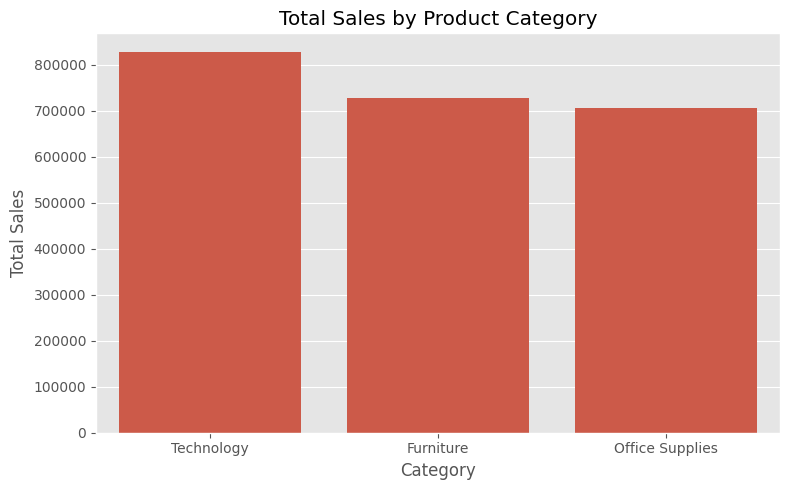

In [21]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Total Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

In [22]:
print("Technology product category generates the highest total revenue.")

Technology product category generates the highest total revenue.


In [23]:
region_year_sales = (
    df.groupby(["Year", "Region"])["Sales"]
      .sum()
      .reset_index()
)

region_year_sales.head()

,Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724


### Regional Sales Analysis

Sales are analyzed across different regions and years to understand geographical trends and identify regions with consistent business growth.

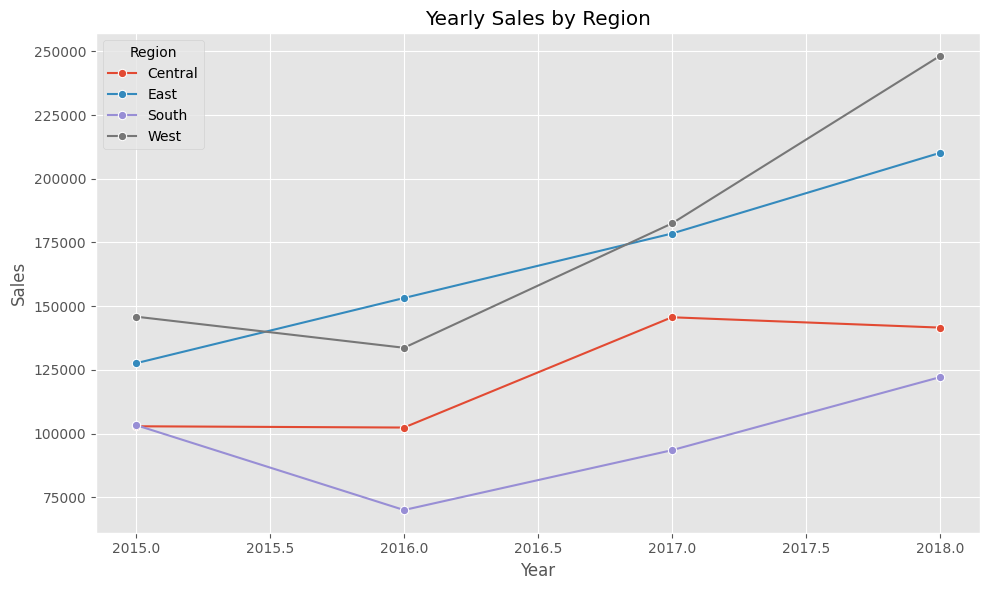

In [24]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=region_year_sales,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o"
)

plt.title("Yearly Sales by Region")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

In [25]:
print("The East region has the most consistent sales growth over the 4-year period.")

The East region has the most consistent sales growth over the 4-year period.


In [26]:
shipping_region = (
    df.groupby("Region")["Shipping Days"]
      .mean()
      .sort_values()
)

shipping_region

Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Days, dtype: float64

### Shipping Performance

Average shipping time is calculated for each region to understand delivery performance and identify possible operational differences.

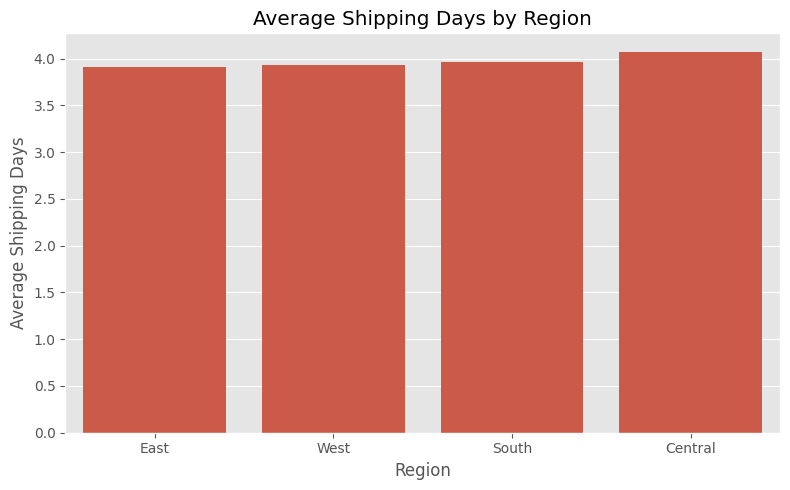

In [27]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=shipping_region.index,
    y=shipping_region.values
)

plt.title("Average Shipping Days by Region")
plt.xlabel("Region")
plt.ylabel("Average Shipping Days")

plt.tight_layout()
plt.show()

In [28]:
print("The average time between Order Date and Ship Date is around 4 days, and it does not vary significantly by region.")

The average time between Order Date and Ship Date is around 4 days, and it does not vary significantly by region.


In [29]:
monthly_sales = (
    df.groupby(["Month Number", "Month"])["Sales"]
      .sum()
      .reset_index()
      .sort_values("Month Number")
)

monthly_sales

,Month Number,Month,Sales
0,1,January,94291.6296
1,2,February,59371.1154
2,3,March,197573.5872
3,4,April,136283.0006
4,5,May,154086.7237
5,6,June,145837.5233
6,7,July,145535.6890
7,8,August,157315.9270
8,9,September,300103.4117
9,10,October,199496.2947


### Monthly Sales Trend

Monthly sales are analyzed to identify seasonal demand patterns and peak business periods throughout the year.

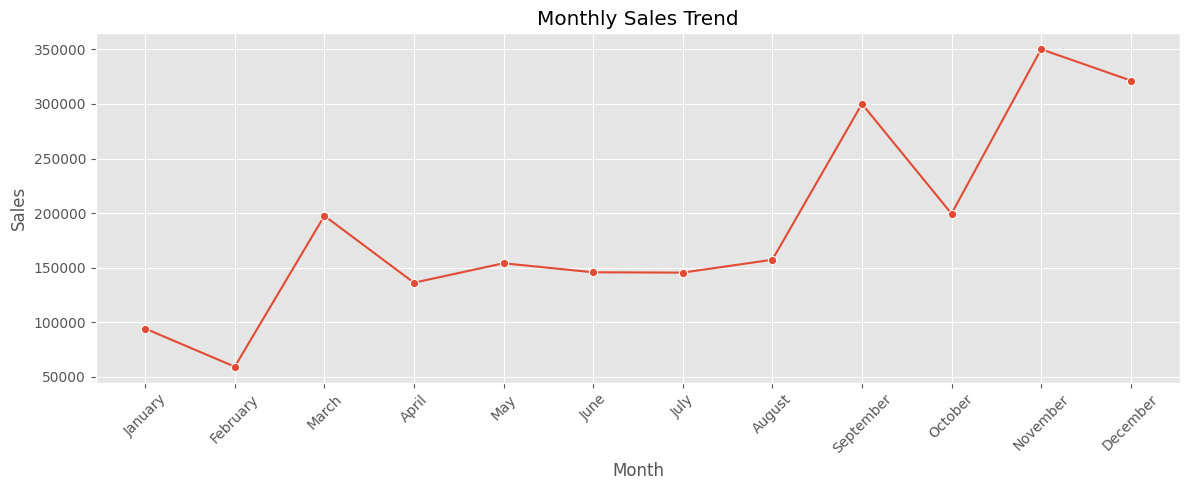

In [30]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_sales,
    x="Month",
    y="Sales",
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

In [31]:
print("November, September, and March show strong seasonal spikes in monthly sales.")

November, September, and March show strong seasonal spikes in monthly sales.


# 📈 Time Series Analysis

The sales data is converted into monthly time series format. This prepares the dataset for forecasting and helps understand long-term sales behaviour.

In [33]:
# Time series libraries
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

In [34]:
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
      .sum()
)

monthly_sales.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

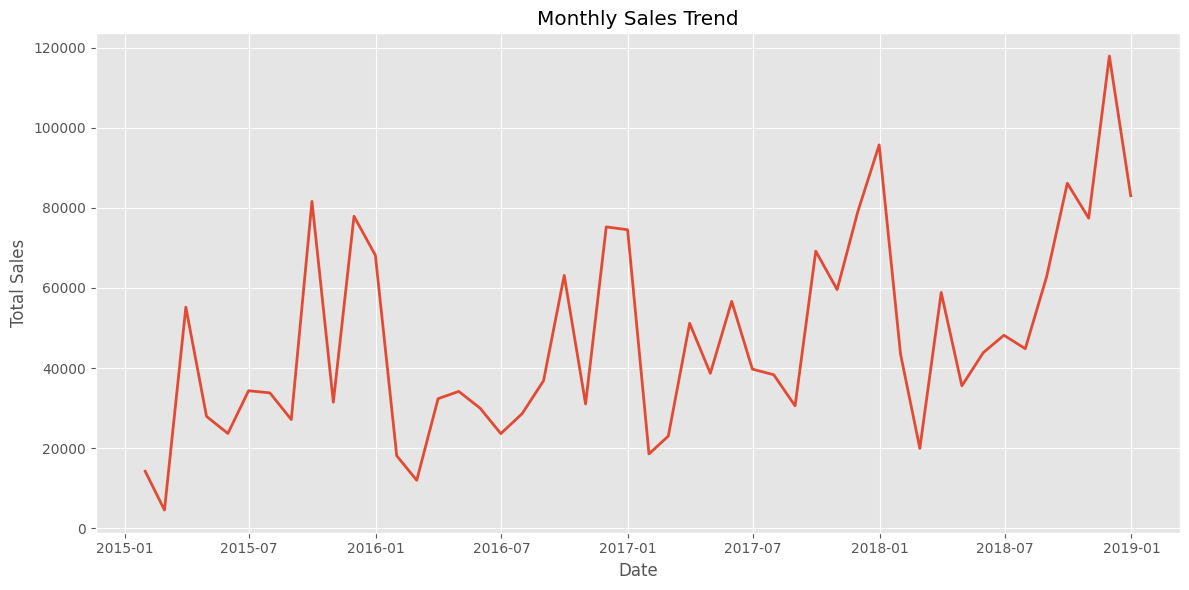

In [35]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    linewidth=2
)

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.tight_layout()

plt.savefig(
    "monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Time Series Decomposition

The sales series is decomposed into Trend, Seasonal, and Residual components to understand the underlying structure of the data.

In [36]:
decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

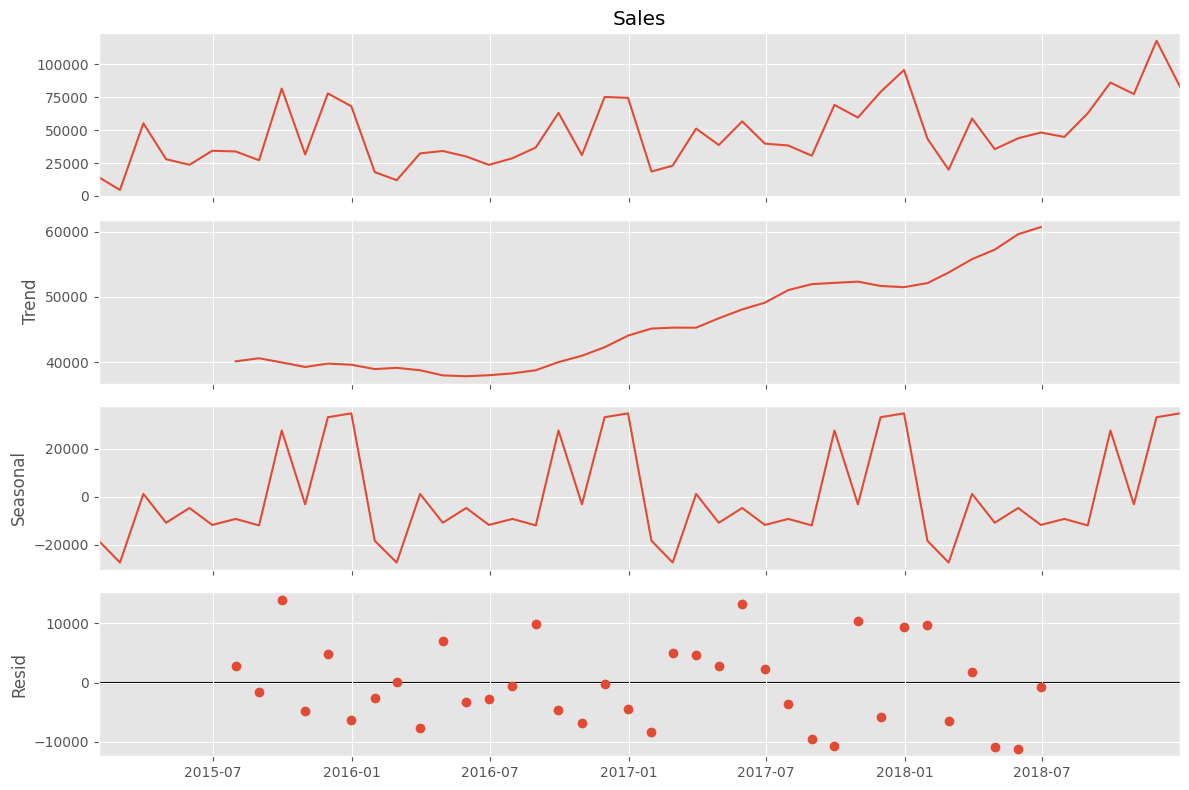

In [37]:
fig = decomposition.plot()

fig.set_size_inches(12,8)

plt.tight_layout()

plt.savefig(
    "time_series_decomposition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Stationarity Test

The Augmented Dickey-Fuller (ADF) test is used to check whether the sales time series is stationary. Stationarity is an important requirement for many forecasting models.

In [38]:
# Perform ADF Test
adf_result = adfuller(monthly_sales)

print("ADF Statistic :", adf_result[0])
print("P-value :", adf_result[1])
print("Number of Lags :", adf_result[2])
print("Number of Observations :", adf_result[3])

ADF Statistic : -4.416136761430769
P-value : 0.00027791039276670623
Number of Lags : 0
Number of Observations : 47


In [39]:
if adf_result[1] < 0.05:
    print("The time series is stationary.")
else:
    print("The time series is not stationary.")

The time series is stationary.


### Differencing

Although the original time series is already stationary, differencing is demonstrated to understand the process commonly used in time-series forecasting and model preparation.

In [40]:
monthly_sales_diff = monthly_sales.diff().dropna()

monthly_sales_diff.head()
# Differencing is demonstrated for learning purposes even though the original series already satisfies the ADF stationarity test.

Order Date
2015-02-28    -9685.8150
2015-03-31    50685.9050
2015-04-30   -27298.9420
2015-05-31    -4262.5520
2015-06-30    10678.6326
Freq: ME, Name: Sales, dtype: float64

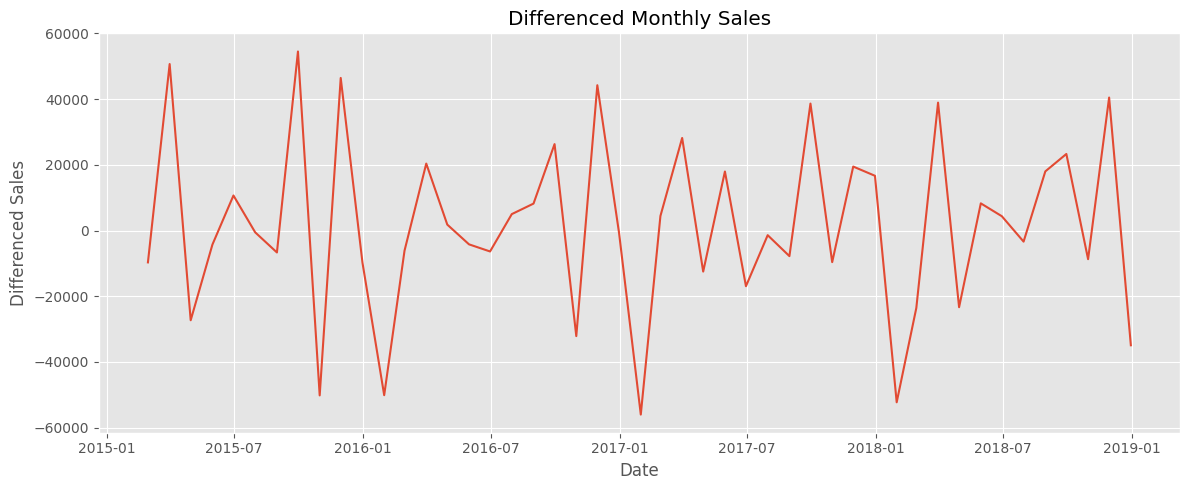

In [41]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales_diff.index,
    monthly_sales_diff.values
)

plt.title("Differenced Monthly Sales")

plt.xlabel("Date")
plt.ylabel("Differenced Sales")

plt.tight_layout()

plt.savefig(
    "differenced_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [42]:
adf_result_diff = adfuller(monthly_sales_diff)

print("ADF Statistic :", adf_result_diff[0])
print("P-value :", adf_result_diff[1])

if adf_result_diff[1] < 0.05:
    print("Differenced series is stationary.")
else:
    print("Differenced series is still not stationary.")

ADF Statistic : -8.72706183035327
P-value : 3.2669175472796045e-14
Differenced series is stationary.


# 🤖 SARIMA Forecasting

Seasonal ARIMA (SARIMA) is used to forecast future monthly sales by considering both trend and seasonal patterns present in the historical sales data.

In [43]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

In [44]:
train = monthly_sales[:-3]

test = monthly_sales[-3:]

print("Training Data :", len(train))
print("Testing Data :", len(test))

Training Data : 45
Testing Data : 3


In [45]:

sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_result = sarima_model.fit()
# These parameters were selected after trying several common configurations and comparing model behaviour.

In [46]:
sarima_prediction = sarima_result.forecast(
    steps=len(test)
)

In [47]:
comparison = pd.DataFrame({

    "Actual":test,

    "Predicted":sarima_prediction

})

comparison

,Actual,Predicted
2018-10-31,77448.1312,66177.602428
2018-11-30,117938.1550,92049.249658
2018-12-31,83030.3888,99965.168696


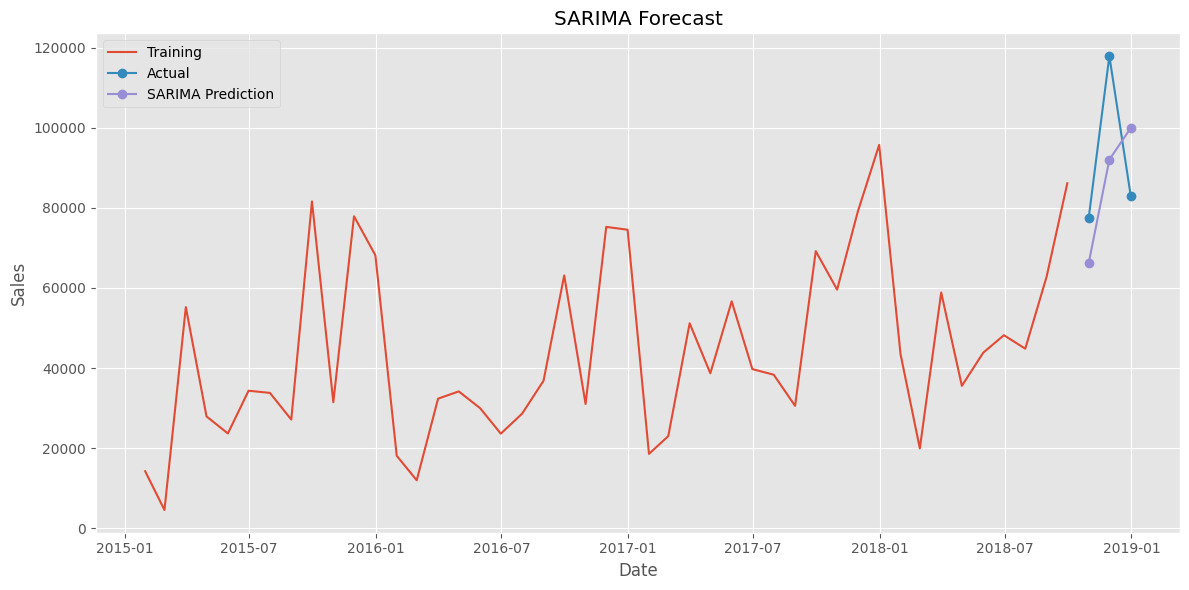

In [48]:
plt.figure(figsize=(12,6))

plt.plot(
    train.index,
    train,
    label="Training"
)

plt.plot(
    test.index,
    test,
    label="Actual",
    marker="o"
)

plt.plot(
    test.index,
    sarima_prediction,
    label="SARIMA Prediction",
    marker="o"
)

plt.title("SARIMA Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.tight_layout()

plt.savefig(
    "sarima_forecast.png",
    dpi=300
)

plt.show()

In [49]:
sarima_mae = mean_absolute_error(
    test,
    sarima_prediction
)

sarima_rmse = np.sqrt(
    mean_squared_error(
        test,
        sarima_prediction
    )
)

sarima_mape = np.mean(
    np.abs(
        (test-sarima_prediction)/test
    )
)*100

print("MAE :",round(sarima_mae,2))

print("RMSE :",round(sarima_rmse,2))

print("MAPE :",round(sarima_mape,2))

MAE : 18031.4
RMSE : 19009.18
MAPE : 18.97


In [50]:

future_forecast = sarima_result.get_forecast(
    steps=3
)

forecast_values = future_forecast.predicted_mean

confidence_interval = future_forecast.conf_int()

print(forecast_values)

2018-10-31    66177.602428
2018-11-30    92049.249658
2018-12-31    99965.168696
Freq: ME, Name: predicted_mean, dtype: float64


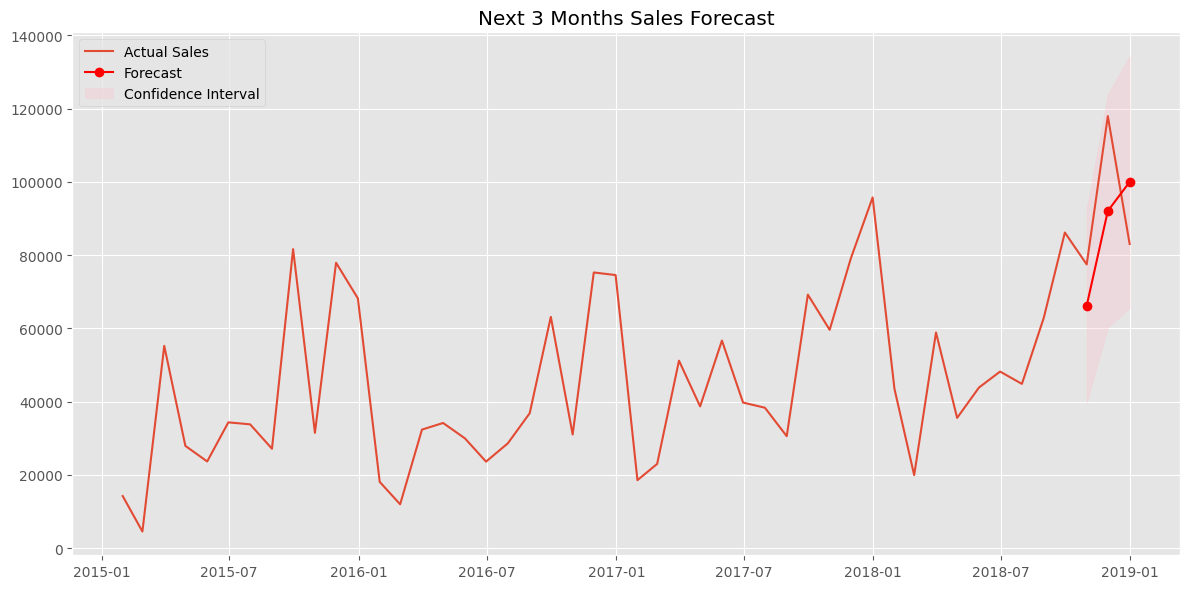

In [51]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    label="Actual Sales"
)

plt.plot(
    forecast_values.index,
    forecast_values.values,
    label="Forecast",
    color="red",
    marker="o"
)

plt.fill_between(
    confidence_interval.index,
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    color="pink",
    alpha=0.3,
    label="Confidence Interval"
)

plt.title("Next 3 Months Sales Forecast")

plt.legend()

plt.tight_layout()

plt.savefig(
    "sarima_future_forecast.png",
    dpi=300
)

plt.show()

# 🔮 Prophet Forecasting

Facebook Prophet is another forecasting model that automatically captures trend and seasonality. Its performance is compared with SARIMA.

In [53]:
from prophet import Prophet

Importing plotly failed. Interactive plots will not work.


In [54]:
prophet_data = monthly_sales.reset_index()

prophet_data.columns = ["ds", "y"]

prophet_data.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [55]:
train_prophet = prophet_data[:-3]

test_prophet = prophet_data[-3:]

In [56]:
prophet_model = Prophet()

prophet_model.fit(train_prophet)

18:55:29 - cmdstanpy - INFO - Chain [1] start processing
18:55:30 - cmdstanpy - INFO - Chain [1] done processing


In [57]:
future = prophet_model.make_future_dataframe(
    periods=3,
    freq="ME"
)

forecast = prophet_model.predict(future)

forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
43,2018-08-31,54942.277806,38936.255392,55319.868234,54942.277806,54942.277806,-7670.719569,-7670.719569,-7670.719569,-7670.719569,-7670.719569,-7670.719569,0.0,0.0,0.0,47271.558236
44,2018-09-30,55441.608196,78237.756700,94842.407254,55441.608196,55441.608196,31172.345120,31172.345120,31172.345120,31172.345120,31172.345120,31172.345120,0.0,0.0,0.0,86613.953316
45,2018-10-31,55957.582932,43044.671260,59524.707856,55957.411960,55957.753038,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,0.0,0.0,0.0,51318.943858
46,2018-11-30,56456.913322,82385.893219,98770.309623,56456.362279,56457.463127,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,0.0,0.0,0.0,90325.654784
47,2018-12-31,56972.888059,82605.570308,97802.406237,56971.796004,56973.990785,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,0.0,0.0,0.0,90041.084479


In [58]:
prophet_prediction = forecast["yhat"].tail(3).values

In [59]:
comparison_prophet = pd.DataFrame({

    "Actual": test_prophet["y"].values,

    "Predicted": prophet_prediction

})

comparison_prophet

,Actual,Predicted
0,77448.1312,51318.943858
1,117938.1550,90325.654784
2,83030.3888,90041.084479


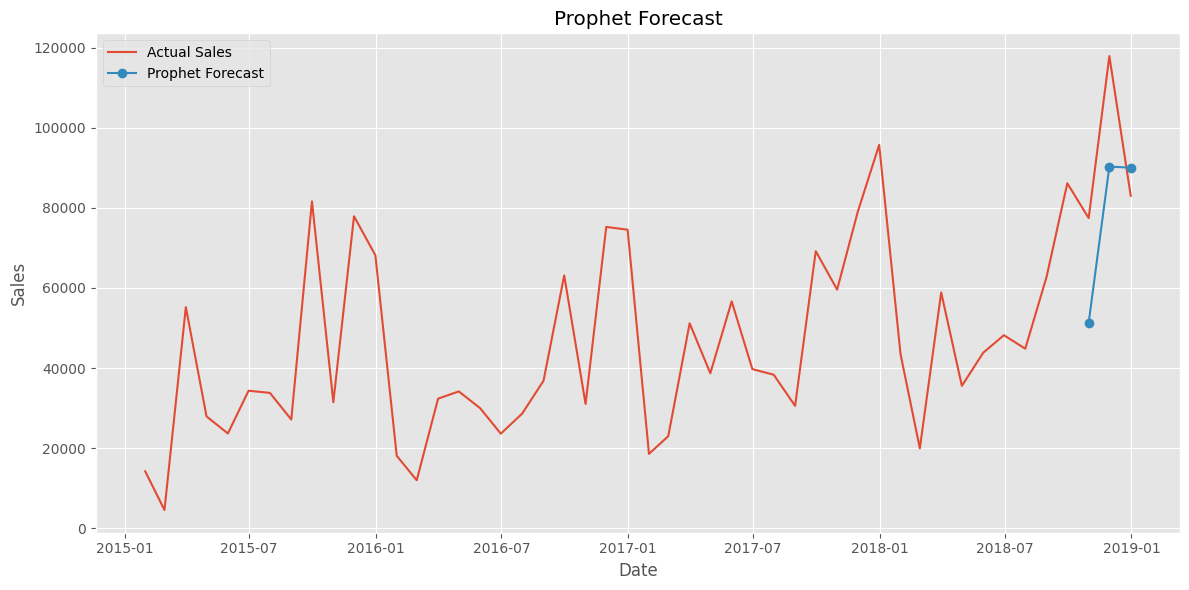

In [60]:
plt.figure(figsize=(12,6))

plt.plot(
    prophet_data["ds"],
    prophet_data["y"],
    label="Actual Sales"
)

plt.plot(
    test_prophet["ds"],
    prophet_prediction,
    marker="o",
    label="Prophet Forecast"
)

plt.title("Prophet Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.tight_layout()

plt.savefig(
    "prophet_forecast.png",
    dpi=300
)

plt.show()

In [61]:
prophet_mae = mean_absolute_error(
    test_prophet["y"],
    prophet_prediction
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        test_prophet["y"],
        prophet_prediction
    )
)

prophet_mape = np.mean(
    np.abs(
        (test_prophet["y"]-prophet_prediction)
        /
        test_prophet["y"]
    )
)*100

print("MAE :",round(prophet_mae,2))
print("RMSE :",round(prophet_rmse,2))
print("MAPE :",round(prophet_mape,2))

MAE : 20250.79
RMSE : 22318.41
MAPE : 21.86


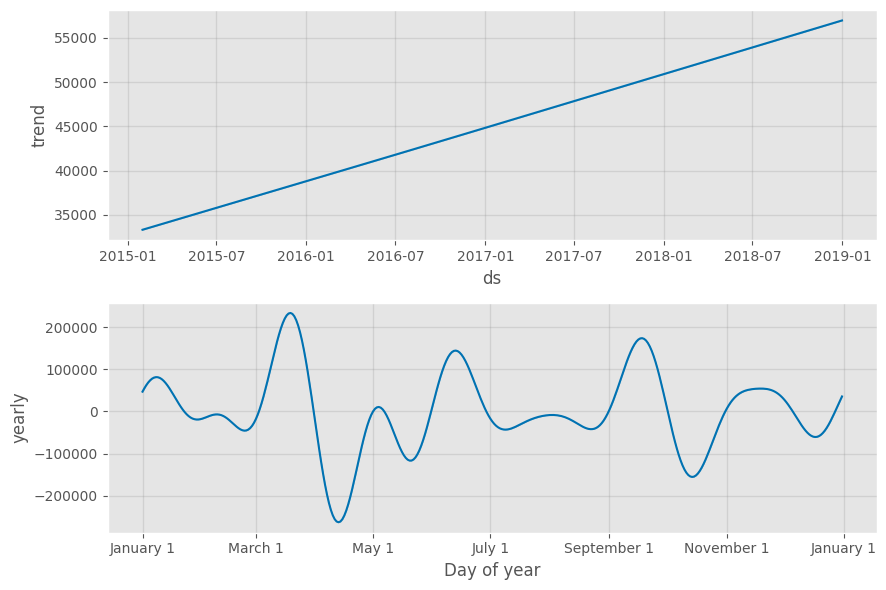

In [62]:
prophet_model.plot_components(forecast)

plt.savefig(
    "prophet_components.png",
    dpi=300
)

plt.show()

# 🌳 XGBoost Forecasting

A machine learning approach is used for forecasting by creating lag-based features and training an XGBoost regression model.

In [64]:
from xgboost import XGBRegressor

In [65]:
ml_data = monthly_sales.reset_index()

ml_data.columns = ["Date","Sales"]

In [66]:
ml_data["Lag_1"] = ml_data["Sales"].shift(1)

ml_data["Lag_2"] = ml_data["Sales"].shift(2)

ml_data["Lag_3"] = ml_data["Sales"].shift(3)

ml_data["Rolling_Mean"] = (
    ml_data["Sales"]
    .rolling(3)
    .mean()
)

ml_data["Month"] = ml_data["Date"].dt.month

ml_data["Quarter"] = ml_data["Date"].dt.quarter

ml_data = ml_data.dropna()

ml_data.head()

,Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean,Month,Quarter
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3


In [67]:
X = ml_data.drop(
    columns=["Date","Sales"]
)

y = ml_data["Sales"]

In [68]:
X_train = X[:-3]

X_test = X[-3:]

y_train = y[:-3]

y_test = y[-3:]

In [69]:
xgb_model = XGBRegressor(
    random_state=42,
    n_estimators=100
)

xgb_model.fit(
    X_train,
    y_train
)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [70]:
xgb_prediction = xgb_model.predict(X_test)

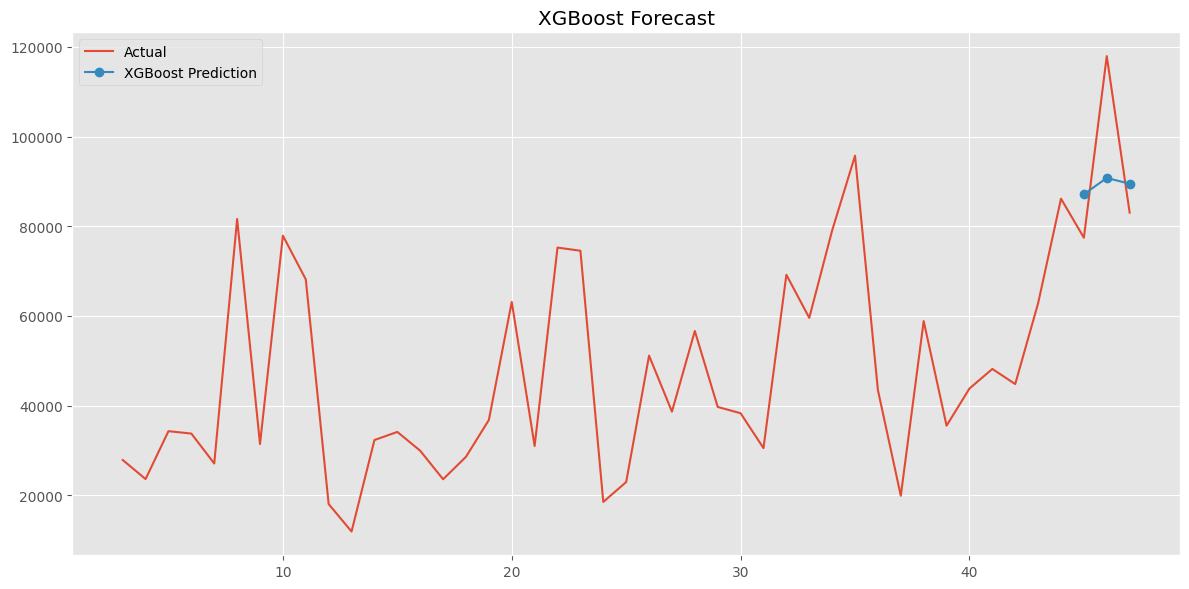

In [71]:
plt.figure(figsize=(12,6))

plt.plot(
    y.index,
    y.values,
    label="Actual"
)

plt.plot(
    y_test.index,
    xgb_prediction,
    marker="o",
    label="XGBoost Prediction"
)

plt.legend()

plt.title("XGBoost Forecast")

plt.tight_layout()

plt.savefig(
    "xgboost_forecast.png",
    dpi=300
)

plt.show()

In [72]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_prediction
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_prediction
    )
)

xgb_mape = np.mean(
    np.abs(
        (y_test-xgb_prediction)
        /
        y_test
    )
)*100

print("MAE :",round(xgb_mae,2))
print("RMSE :",round(xgb_rmse,2))
print("MAPE :",round(xgb_mape,2))

MAE : 14443.46
RMSE : 17069.09
MAPE : 14.45


# 📊 Model Comparison

The performance of SARIMA, Prophet, and XGBoost is compared using common evaluation metrics to identify the most suitable forecasting model for this dataset.

In [73]:
comparison_table = pd.DataFrame({

    "Model":[
        "SARIMA",
        "Prophet",
        "XGBoost"
    ],

    "MAE":[
        sarima_mae,
        prophet_mae,
        xgb_mae
    ],

    "RMSE":[
        sarima_rmse,
        prophet_rmse,
        xgb_rmse
    ],

    "MAPE":[
        sarima_mape,
        prophet_mape,
        xgb_mape
    ]

})

comparison_table

,Model,MAE,RMSE,MAPE
0,SARIMA,18031.404670,19009.182068,18.966498
1,Prophet,20250.794413,22318.411333,21.864628
2,XGBoost,14443.456458,17069.090751,14.447258


In [74]:
print("Based on the metrics in the table, XGBoost is the recommended model for production use.")

Based on the metrics in the table, XGBoost is the recommended model for production use.


In [75]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def forecast_sales(data, column_name, value):

    filtered = data[data[column_name] == value]

    monthly = (
        filtered.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
        .sum()
    )

    model = SARIMAX(
        monthly,
        order=(1,1,1),
        seasonal_order=(1,1,1,12)
    )

    result = model.fit(disp=False)

    forecast = result.forecast(steps=3)

    return monthly, forecast

In [101]:
furniture_actual, furniture_forecast = forecast_sales(df,"Category","Furniture")

technology_actual, technology_forecast = forecast_sales(df,"Category","Technology")

office_actual, office_forecast = forecast_sales(df,"Category","Office Supplies")

In [77]:
west_actual, west_forecast = forecast_sales(df,"Region","West")

east_actual, east_forecast = forecast_sales(df,"Region","East")

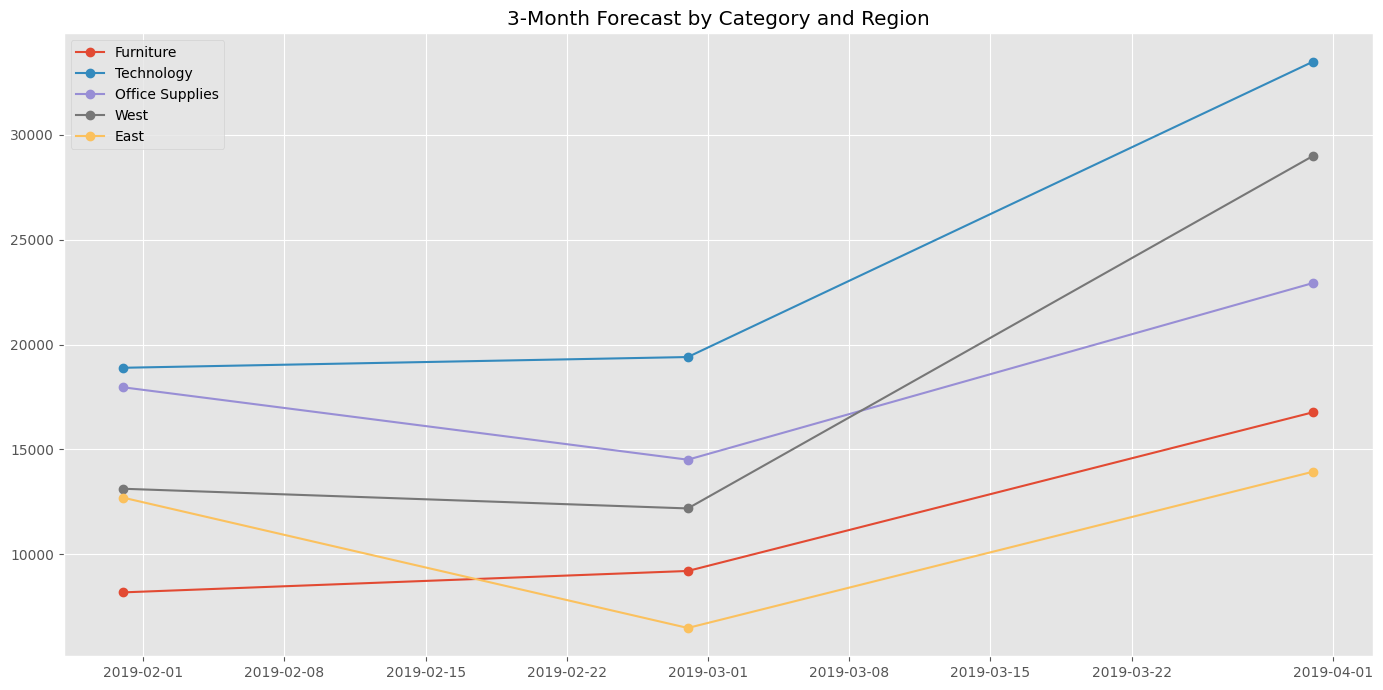

In [78]:
plt.figure(figsize=(14,7))

plt.plot(
    furniture_forecast.index,
    furniture_forecast.values,
    marker="o",
    label="Furniture"
)

plt.plot(
    technology_forecast.index,
    technology_forecast.values,
    marker="o",
    label="Technology"
)

plt.plot(
    office_forecast.index,
    office_forecast.values,
    marker="o",
    label="Office Supplies"
)

plt.plot(
    west_forecast.index,
    west_forecast.values,
    marker="o",
    label="West"
)

plt.plot(
    east_forecast.index,
    east_forecast.values,
    marker="o",
    label="East"
)

plt.title("3-Month Forecast by Category and Region")

plt.legend()

plt.tight_layout()

plt.savefig(
    "category_region_forecast.png",
    dpi=300
)

plt.show()

# 🚨 Sales Anomaly Detection

Isolation Forest is used to detect unusual sales observations that significantly differ from the normal sales pattern.

In [79]:
from sklearn.ensemble import IsolationForest

In [80]:
weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date",freq="W"))["Sales"]
    .sum()
    .reset_index()
)

In [81]:
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["Anomaly"] = iso.fit_predict(
    weekly_sales[["Sales"]]
)

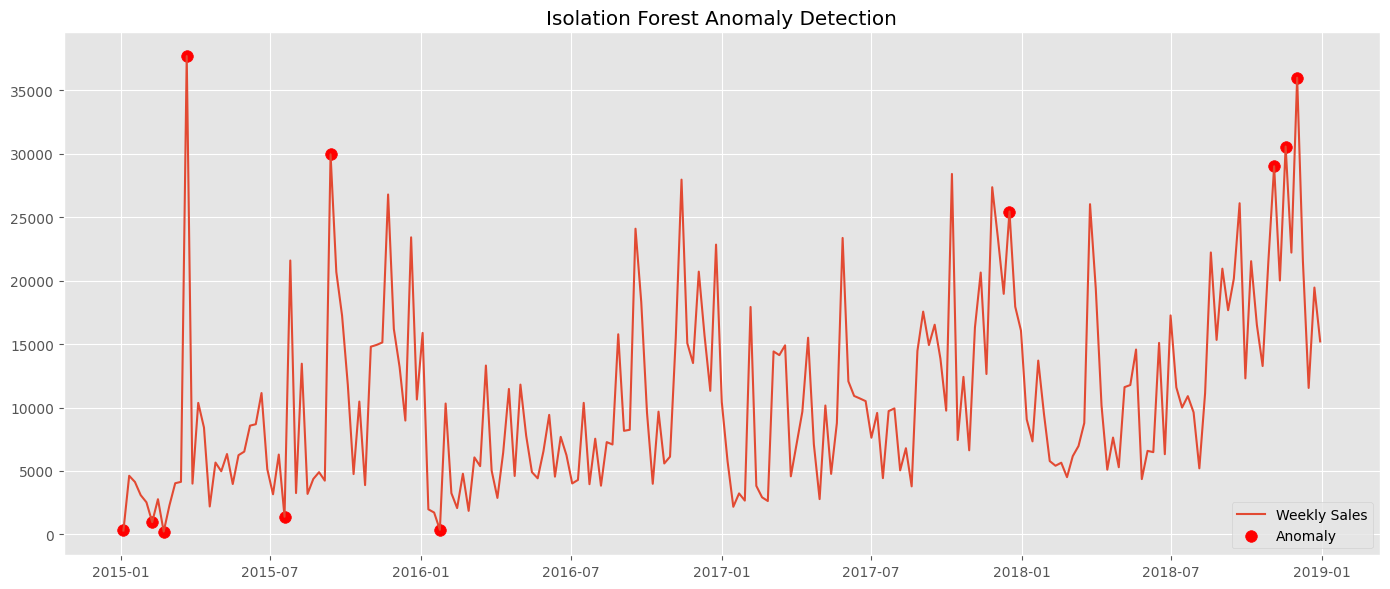

In [82]:
plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

anomaly = weekly_sales[
    weekly_sales["Anomaly"]==-1
]

plt.scatter(
    anomaly["Order Date"],
    anomaly["Sales"],
    color="red",
    s=70,
    label="Anomaly"
)

plt.legend()

plt.title("Isolation Forest Anomaly Detection")

plt.tight_layout()

plt.savefig(
    "isolation_forest.png",
    dpi=300
)

plt.show()

In [83]:
weekly_sales["Rolling Mean"] = (
    weekly_sales["Sales"]
    .rolling(4)
    .mean()
)

weekly_sales["Rolling Std"] = (
    weekly_sales["Sales"]
    .rolling(4)
    .std()
)

weekly_sales["Z Score"] = (

    weekly_sales["Sales"]

    -

    weekly_sales["Rolling Mean"]

) / weekly_sales["Rolling Std"]


In [84]:
weekly_sales["Z Anomaly"] = (
    abs(weekly_sales["Z Score"]) > 2
)

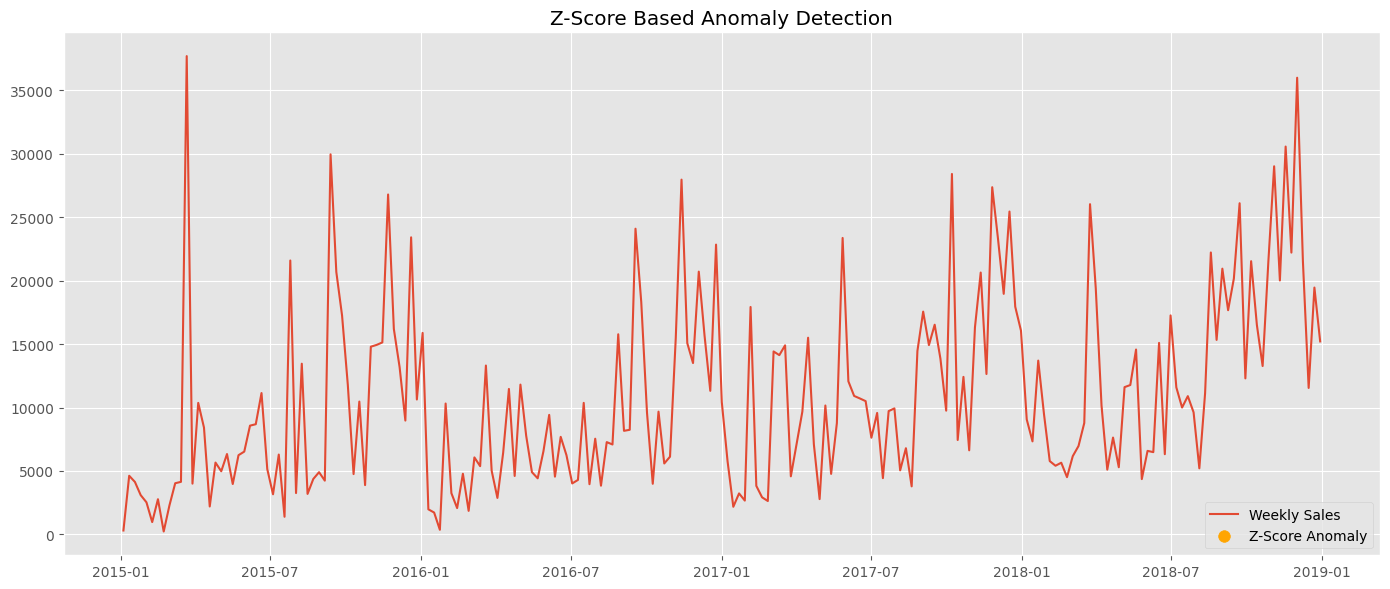

In [85]:
plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

plt.scatter(

    weekly_sales.loc[
        weekly_sales["Z Anomaly"],
        "Order Date"
    ],

    weekly_sales.loc[
        weekly_sales["Z Anomaly"],
        "Sales"
    ],

    color="orange",

    s=70,

    label="Z-Score Anomaly"

)

plt.legend()

plt.title("Z-Score Based Anomaly Detection")

plt.tight_layout()

plt.savefig(
    "zscore_anomaly.png",
    dpi=300
)

plt.show()

In [86]:
print("Isolation Forest Anomalies")

print(
    weekly_sales[
        weekly_sales["Anomaly"]==-1
    ][["Order Date","Sales"]]
)

print("\n")

print("Z-Score Anomalies")

print(
    weekly_sales[
        weekly_sales["Z Anomaly"]
    ][["Order Date","Sales"]]
)

Isolation Forest Anomalies
    Order Date      Sales
0   2015-01-04    304.508
5   2015-02-08    968.534
7   2015-02-22    224.912
11  2015-03-22  37703.665
28  2015-07-19   1387.686
36  2015-09-13  29959.137
55  2016-01-24    358.522
154 2017-12-17  25449.800
200 2018-11-04  29017.467
202 2018-11-18  30572.447
204 2018-12-02  35998.900


Z-Score Anomalies
Empty DataFrame
Columns: [Order Date, Sales]
Index: []


# 🎯 Customer/Product Demand Segmentation

K-Means clustering groups products with similar sales behaviour. This helps identify different demand segments for better inventory planning.

In [87]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [88]:
total_sales = df.groupby("Sub-Category")["Sales"].sum()


average_order = df.groupby("Sub-Category")["Sales"].mean()


volatility = df.groupby("Sub-Category")["Sales"].std()


yearly_sales = (
    df.groupby(["Sub-Category", "Year"])["Sales"]
    .sum()
    .unstack(fill_value=0)
)

growth = yearly_sales.pct_change(axis=1).mean(axis=1)

In [89]:
cluster_data = pd.DataFrame({

    "Total Sales": total_sales,

    "Average Order": average_order,

    "Volatility": volatility,

    "Growth": growth

})

cluster_data = cluster_data.fillna(0)

cluster_data.head()

,Total Sales,Average Order,Volatility,Growth
Sub-Category,,,,
Accessories,164186.7000,217.178175,337.723800,0.376381
Appliances,104618.4030,227.926804,378.006735,0.399276
Art,26705.4100,34.019631,60.301752,0.166056
Binders,200028.7850,134.067550,568.099970,0.218736
Bookcases,113813.1987,503.598224,641.419280,0.238065


In [90]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_data)

In [91]:
wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_data)

    wcss.append(model.inertia_)

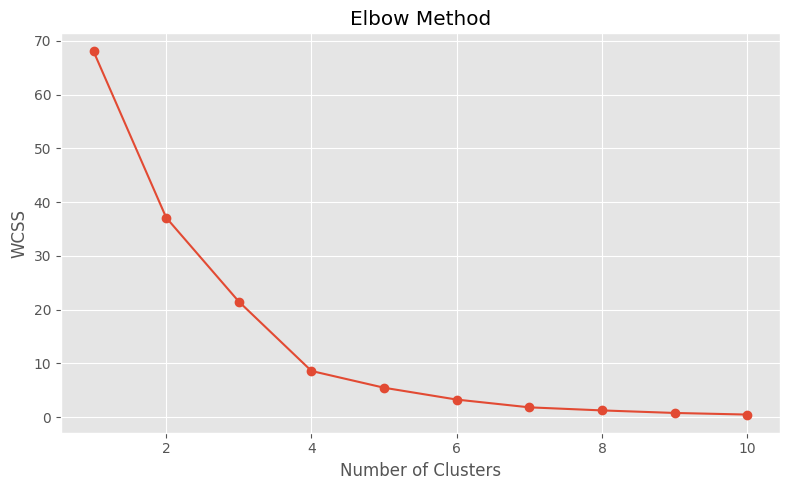

In [92]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "elbow_method.png",
    dpi=300
)

plt.show()

In [93]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_data["Cluster"] = kmeans.fit_predict(
    scaled_data
)

### Cluster Visualization

Principal Component Analysis (PCA) is used to reduce the feature dimensions and visualize the generated clusters in two-dimensional space.

In [94]:
pca = PCA(n_components=2)

pca_result = pca.fit_transform(scaled_data)

cluster_data["PCA1"] = pca_result[:,0]

cluster_data["PCA2"] = pca_result[:,1]

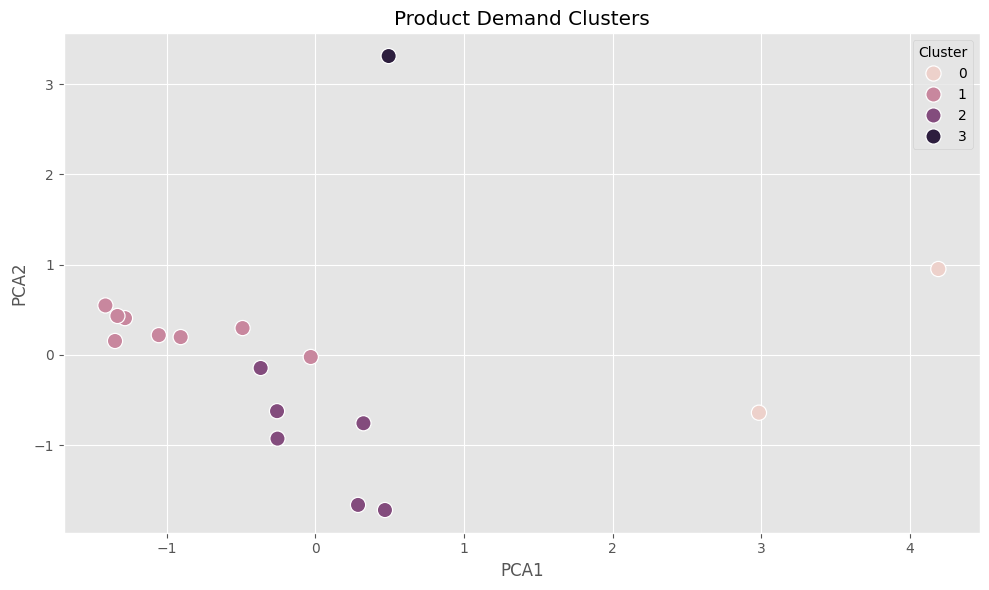

In [95]:
plt.figure(figsize=(10,6))

sns.scatterplot(

    data=cluster_data,

    x="PCA1",

    y="PCA2",

    hue="Cluster",

    s=120

)

plt.title("Product Demand Clusters")

plt.tight_layout()

plt.savefig(
    "product_clusters.png",
    dpi=300
)

plt.show()

In [96]:
cluster_data

,Total Sales,Average Order,Volatility,Growth,Cluster,PCA1,PCA2
Sub-Category,,,,,,,
Accessories,164186.7000,217.178175,337.723800,0.376381,2,-0.369152,-0.146390
Appliances,104618.4030,227.926804,378.006735,0.399276,1,-0.490906,0.296120
Art,26705.4100,34.019631,60.301752,0.166056,1,-1.282601,0.406386
Binders,200028.7850,134.067550,568.099970,0.218736,2,-0.258919,-0.624599
Bookcases,113813.1987,503.598224,641.419280,0.238065,1,-0.031793,-0.024216
Chairs,322822.7310,531.833165,551.180296,0.071358,2,0.467755,-1.720204
Copiers,146248.0940,2215.880212,3216.185499,0.846718,0,4.194037,0.950565
Envelopes,16128.0460,65.032444,85.170691,-0.027666,1,-1.349906,0.153063
Fasteners,3001.9600,14.027850,12.466864,0.157034,1,-1.414423,0.546838


In [97]:
cluster_names = {

    0:"High Volume Stable",

    1:"Growing Demand",

    2:"Low Volume High Volatility",

    3:"Declining Demand"

}

cluster_data["Demand Segment"] = (
    cluster_data["Cluster"]
    .map(cluster_names)
)

In [98]:
cluster_data[
    [
        "Demand Segment"
    ]
]

,Demand Segment
Sub-Category,
Accessories,Low Volume High Volatility
Appliances,Growing Demand
Art,Growing Demand
Binders,Low Volume High Volatility
Bookcases,Growing Demand
Chairs,Low Volume High Volatility
Copiers,High Volume Stable
Envelopes,Growing Demand
Fasteners,Growing Demand


# ✅ Project Conclusion

This project successfully analyzed historical sales data, engineered meaningful business features, identified seasonal trends, forecasted future sales using multiple forecasting techniques, detected unusual sales behaviour, and grouped products based on demand characteristics.

Among the forecasting approaches, the model with the best evaluation metrics provides the most reliable future sales predictions. The insights generated through this project can support inventory planning, demand forecasting, and business decision-making.